In [125]:

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.calibration import CalibratedClassifierCV
from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.metrics import log_loss, roc_auc_score, brier_score_loss, classification_report
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBClassifier



In [13]:
path = r"C:\Users\bhavy\Massachusetts Institute of Technology\Truck Parking Capstone - General\Truck Stop Finder 🚚⛽\\"
# path = r"C:\Users\samcl\Massachusetts Institute of Technology\Truck Parking Capstone - Truck Stop Finder 🚚⛽\\"

In [14]:
# Sourced directly from TruckerPath
park_data_1 = pd.read_csv(
    path + r"5. Source & Refrence Files\0. TruckerPath Data\MIT_2025_High_Volume_Routes_Parking_Data_1 - Copy.csv")
park_data_2 = pd.read_csv(
    path + r"5. Source & Refrence Files\0. TruckerPath Data\MIT_2025_High_Volume_Routes_Parking_Data_2 - Copy.csv")
park_data_3 = pd.read_csv(
    path + r"5. Source & Refrence Files\0. TruckerPath Data\MIT_2025_High_Volume_Routes_Parking_Data_3 - Copy.csv")
park_data = pd.concat([park_data_1, park_data_2, park_data_3], ignore_index=True)

In [15]:
truck_stop = pd.read_excel("output_excel\Model_Stops_V3.xlsx")

In [16]:
avail_park = park_data[park_data["pin id"].isin(truck_stop["pin id"].unique())].copy()

In [19]:
avail_park["ts_utc"] = pd.to_datetime(avail_park["time(utc)"], utc=True)

In [20]:
print(avail_park["ts_utc"].isna().mean(), "fraction of timestamps failed to parse")
print(avail_park["ts_utc"].min(), "to", avail_park["ts_utc"].max())

0.0 fraction of timestamps failed to parse
2024-11-07 00:00:00+00:00 to 2025-11-07 00:45:01+00:00


In [7]:
avail_park["day_of_week"] = avail_park["time(utc)"].dt.dayofweek
avail_park["day_name"] = avail_park["time(utc)"].dt.day_name()
avail_park["hour"] = avail_park["time(utc)"].dt.hour
avail_park["month"] = avail_park["time(utc)"].dt.month
avail_park["date"] = avail_park["time(utc)"].dt.day

In [30]:
avail_park = avail_park[avail_park["parking status"] != 'Paid'].copy()

In [31]:
avail_park.head(2)

,pinname,parking status,time(utc),pinlat,pinlon,pin id,object,city,route_num,ts_utc,gap_prev,gap_prev_min
1353040,Truck Spot Properties,Some,2025-01-15 11:23:23+00:00,30.406303,-81.743304,00038787e666dbf59f419128a0ee3a66,Parking,Jacksonville,295,2025-01-15 11:23:23+00:00,26 days 01:24:30,37524.500000
1353050,Truck Spot Properties,Some,2025-02-06 13:43:22+00:00,30.406303,-81.743304,00038787e666dbf59f419128a0ee3a66,Parking,Jacksonville,295,2025-02-06 13:43:22+00:00,22 days 02:19:59,31819.983333


In [32]:
avail_park = avail_park.sort_values(["pin id", "ts_utc"])

In [33]:
avail_park["gap_prev"] = avail_park.groupby("pin id")["ts_utc"].diff()
avail_park["gap_prev_min"] = avail_park["gap_prev"].dt.total_seconds() / 60

In [34]:
avail_park

,pinname,parking status,time(utc),pinlat,pinlon,pin id,object,city,route_num,ts_utc,gap_prev,gap_prev_min
1353040,Truck Spot Properties,Some,2025-01-15 11:23:23+00:00,30.406303,-81.743304,00038787e666dbf59f419128a0ee3a66,Parking,Jacksonville,295,2025-01-15 11:23:23+00:00,NaT,NaN
1353050,Truck Spot Properties,Some,2025-02-06 13:43:22+00:00,30.406303,-81.743304,00038787e666dbf59f419128a0ee3a66,Parking,Jacksonville,295,2025-02-06 13:43:22+00:00,22 days 02:19:59,31819.983333
1353025,Truck Spot Properties,Some,2025-08-10 12:23:31+00:00,30.406303,-81.743304,00038787e666dbf59f419128a0ee3a66,Parking,Jacksonville,295,2025-08-10 12:23:31+00:00,184 days 22:40:09,266320.150000
1353043,Truck Spot Properties,Lots,2025-09-25 19:09:58+00:00,30.406303,-81.743304,00038787e666dbf59f419128a0ee3a66,Parking,Jacksonville,295,2025-09-25 19:09:58+00:00,46 days 06:46:27,66646.450000
65,Rest Area WB,Lots,2024-11-07 01:02:59+00:00,30.612343,-86.978559,005b00cc243fb4f39296fa0f16a21482,Rest Area,Milton,10,2024-11-07 01:02:59+00:00,NaT,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
1230499,Alpha Truck Center,Lots,2025-07-08 15:51:37+00:00,30.324783,-81.765593,ff54a86f51cf791a850133ddc157b364,Parking,Jacksonville,295,2025-07-08 15:51:37+00:00,124 days 21:23:00,179843.000000
1230498,Alpha Truck Center,Full,2025-07-10 19:19:07+00:00,30.324783,-81.765593,ff54a86f51cf791a850133ddc157b364,Parking,Jacksonville,295,2025-07-10 19:19:07+00:00,2 days 03:27:30,3087.500000
1230489,Alpha Truck Center,Full,2025-08-13 13:33:58+00:00,30.324783,-81.765593,ff54a86f51cf791a850133ddc157b364,Parking,Jacksonville,295,2025-08-13 13:33:58+00:00,33 days 18:14:51,48614.850000
1230493,Alpha Truck Center,Some,2025-08-21 18:39:16+00:00,30.324783,-81.765593,ff54a86f51cf791a850133ddc157b364,Parking,Jacksonville,295,2025-08-21 18:39:16+00:00,8 days 05:05:18,11825.300000


In [35]:
print(avail_park["gap_prev_min"].describe(percentiles=[0.5, 0.9, 0.95, 0.99]))

count    1.500750e+06
mean     2.494784e+02
std      1.783641e+03
min      0.000000e+00
50%      4.800000e+01
90%      4.709183e+02
95%      8.278333e+02
99%      2.848242e+03
max      3.486706e+05
Name: gap_prev_min, dtype: float64


In [36]:
gap_by_stop = (
    avail_park.dropna(subset=["gap_prev_min"])
    .groupby("pin id")["gap_prev_min"]
    .median()
    .sort_values(ascending=False)
)

print("\nTop 10 sparsest stops by median gap (minutes):")
print(gap_by_stop.head(10))


Top 10 sparsest stops by median gap (minutes):
pin id
82d3149fc1f8d2305e7c6d56a6c5689d    348670.600000
07ff46bb6597a4f81eed4f59360ff835    130567.566667
2ef3dce7c059b268cf8b9e0707ee5594     91115.591667
9dfe23c73e66eab605c9933e87bc1be4     89555.350000
b9455142fde192318faacc5da330a981     76605.075000
c92960867556ab600dd664651920f338     76543.866667
808d5bc180e7b1939e3822e50cd2ff2e     70458.283333
3c4612e833e765c657e2b8877a5c467c     67635.616667
00038787e666dbf59f419128a0ee3a66     66646.450000
8e5d5b79456a8e2bc09e54e9e518a5f1     62186.383333
Name: gap_prev_min, dtype: float64


In [38]:
status_map = {
    "Full": 0,
    "Some": 1,
    "Lots": 2
}

avail_park["status_ord"] = avail_park["parking status"].map(status_map)

In [55]:
LABEL_TOL = pd.Timedelta("60min")  # ±60 min for label lookup
STALE_CUTOFF = pd.Timedelta("6h")  # 6h staleness rule for last_known_status

obs = avail_park[["pin id", "ts_utc", "status_ord", "parking status"]].dropna(subset=["ts_utc", "status_ord"])
# obs = obs.sort_values(["pin id", "ts_utc"])
obs_sorted = obs.dropna(subset=["ts_utc"]).sort_values(["ts_utc", "pin id"]).reset_index(drop=True)

In [56]:
obs

,pin id,ts_utc,status_ord,parking status
1353040,00038787e666dbf59f419128a0ee3a66,2025-01-15 11:23:23+00:00,1,Some
1353050,00038787e666dbf59f419128a0ee3a66,2025-02-06 13:43:22+00:00,1,Some
1353025,00038787e666dbf59f419128a0ee3a66,2025-08-10 12:23:31+00:00,1,Some
1353043,00038787e666dbf59f419128a0ee3a66,2025-09-25 19:09:58+00:00,2,Lots
65,005b00cc243fb4f39296fa0f16a21482,2024-11-07 01:02:59+00:00,2,Lots
...,...,...,...,...
1230499,ff54a86f51cf791a850133ddc157b364,2025-07-08 15:51:37+00:00,2,Lots
1230498,ff54a86f51cf791a850133ddc157b364,2025-07-10 19:19:07+00:00,0,Full
1230489,ff54a86f51cf791a850133ddc157b364,2025-08-13 13:33:58+00:00,0,Full
1230493,ff54a86f51cf791a850133ddc157b364,2025-08-21 18:39:16+00:00,1,Some


In [65]:
# ---- 2) Helper A: last observation at or before query time (decision-time features)
def attach_last_obs_before(query_df, time_col="query_ts"):
    """
    query_df must have columns: ['pin id', time_col]
    Returns query_df + last observed status at/before query_ts and staleness.
    """
    q = query_df.copy()
    q[time_col] = pd.to_datetime(q[time_col], utc=True, errors="coerce")
    # q = q.sort_values(["pin id", time_col], ignore_index=True)
    q = q.dropna(subset=[time_col]).sort_values([time_col, "pin id"]).reset_index(drop=True)

    out = pd.merge_asof(
        q,
        obs_sorted.rename(
            columns={"ts_utc": "last_ts", "status_ord": "last_status_ord", "parking status": "last_status_txt"}),
        left_on=time_col,
        right_on="last_ts",
        by="pin id",
        direction="backward",  # <= query time
        allow_exact_matches=True
    )

    out["time_since_last_obs_min"] = (out[time_col] - out["last_ts"]).dt.total_seconds() / 60

    # Apply 6h staleness rule: if too old, treat last_known_status as unknown (but keep staleness numeric)
    too_stale = (out[time_col] - out["last_ts"]) > STALE_CUTOFF
    out.loc[too_stale, ["last_status_ord", "last_status_txt", "last_ts"]] = pd.NA

    return out


# ---- 3) Helper B: nearest observation within ±60 minutes (labels around ETA)
def attach_label_nearest(query_df, time_col="eta_ts"):
    """
    query_df must have columns: ['pin id', time_col]
    Returns query_df + label status closest to eta_ts within ±60 minutes.
    If no observation within tolerance, label fields stay NA.
    """
    q = query_df.copy()
    q[time_col] = pd.to_datetime(q[time_col], utc=True, errors="coerce")
    # q = q.sort_values(["pin id", time_col])
    q = q.dropna(subset=[time_col]).sort_values([time_col, "pin id"]).reset_index(drop=True)

    out = pd.merge_asof(
        q,
        obs_sorted.rename(
            columns={"ts_utc": "label_ts", "status_ord": "label_status_ord", "parking status": "label_status_txt"}),
        left_on=time_col,
        right_on="label_ts",
        by="pin id",
        direction="nearest",
        tolerance=LABEL_TOL,
        allow_exact_matches=True
    )

    out["label_time_error_min"] = (out["label_ts"] - out[time_col]).abs().dt.total_seconds() / 60
    return out


In [74]:
test_q = avail_park[["pin id", "ts_utc"]].dropna().sample(5, random_state=0)
test_q = test_q.rename(columns={"ts_utc": "query_ts"})
test_q["query_ts"] = test_q["query_ts"] + pd.Timedelta("17min")

In [75]:
print("=== Last obs before (features) ===")
attach_last_obs_before(test_q, time_col="query_ts")

=== Last obs before (features) ===


,pin id,query_ts,last_ts,last_status_ord,last_status_txt,time_since_last_obs_min
0,ec0f40c389aeef789ce03eb814facc6c,2024-11-07 20:58:13+00:00,2024-11-07 20:41:13+00:00,2.0,Lots,17.0
1,3a0c6a979d63c53dd0156aa6441049df,2024-12-13 02:44:13+00:00,2024-12-13 02:27:13+00:00,0.0,Full,17.0
2,d6baf65e0b240ce177cf70da146c8dc8,2025-07-23 16:16:38+00:00,2025-07-23 15:59:38+00:00,2.0,Lots,17.0
3,8b4066554730ddfaa0266346bdc1b202,2025-08-30 19:04:48+00:00,2025-08-30 18:47:48+00:00,2.0,Lots,17.0
4,69307a4b5f719fcb4dd798565db2c28d,2025-11-01 22:14:22+00:00,2025-11-01 21:57:22+00:00,0.0,Full,17.0


In [73]:
test_eta = test_q.copy()
test_eta["eta_ts"] = test_eta["query_ts"] + pd.Timedelta("60min")

print("\n=== Nearest within ±60min (label) ===")
attach_label_nearest(test_eta[["pin id", "eta_ts"]], time_col="eta_ts")


=== Nearest within ±60min (label) ===


,pin id,eta_ts,label_ts,label_status_ord,label_status_txt,label_time_error_min
0,ec0f40c389aeef789ce03eb814facc6c,2024-11-07 21:41:13+00:00,2024-11-07 21:24:16+00:00,2,Lots,16.950000
1,3a0c6a979d63c53dd0156aa6441049df,2024-12-13 03:27:13+00:00,2024-12-13 04:16:12+00:00,0,Full,48.983333
2,d6baf65e0b240ce177cf70da146c8dc8,2025-07-23 16:59:38+00:00,2025-07-23 16:58:06+00:00,2,Lots,1.533333
3,8b4066554730ddfaa0266346bdc1b202,2025-08-30 19:47:48+00:00,2025-08-30 19:09:48+00:00,2,Lots,38.000000
4,69307a4b5f719fcb4dd798565db2c28d,2025-11-01 22:57:22+00:00,2025-11-01 22:58:33+00:00,0,Full,1.183333


In [86]:
# ---- Settings for the first batch
N_DECISIONS = 100_000  # start here; later you can go 500k / 1M
MIN_TAU = 15  # min travel time in minutes
MAX_TAU = 180  # max travel time in minutes

# 1) Build a "decision pool" from real observed timestamps
#    We sample from actual rows to get realistic t0 distribution.
decision_pool = avail_park[[
    "pin id", "ts_utc", "pinlat", "pinlon", "city", "route_num", "object"
]].dropna(subset=["pin id", "ts_utc"]).copy()

decisions = decision_pool.sample(N_DECISIONS, random_state=42).rename(columns={"ts_utc": "t_obs"}).copy()

In [87]:
# 2) Sample travel time tau (minutes)
rng = np.random.default_rng(42)
decisions["tau_min"] = rng.integers(MIN_TAU, MAX_TAU + 1, size=len(decisions))
decisions["t0"] = decisions["t_obs"] + pd.to_timedelta(
    rng.integers(1, 46, size=len(decisions)), unit="m"
)

# 3) Compute ETA
decisions["eta_ts"] = decisions["t0"] + pd.to_timedelta(decisions["tau_min"], unit="m")

# 4) Add ETA calendar features (these are allowed; you know ETA at decision time)
decisions["eta_hour"] = decisions["eta_ts"].dt.hour
decisions["eta_day_of_week"] = decisions["eta_ts"].dt.dayofweek  # Monday=0
decisions["eta_month"] = decisions["eta_ts"].dt.month

In [88]:
decisions.head(3)

,pin id,t_obs,pinlat,pinlon,city,route_num,object,tau_min,t0,eta_ts,eta_hour,eta_day_of_week,eta_month
1458245,f8ea2e8463760785106490befc78c339,2025-07-17 11:23:05+00:00,31.580644,-84.086078,Albany,82,Pilot,29,2025-07-17 11:57:05+00:00,2025-07-17 12:26:05+00:00,12,3,7
478726,03e53a706c9445deabe20bfdfb7e0b42,2025-05-13 08:59:34+00:00,30.253404,-82.402622,Sanderson,10,Rest Area,143,2025-05-13 09:39:34+00:00,2025-05-13 12:02:34+00:00,12,1,5
1735554,a24904e5d3ed28eae9225fd787f64a71,2025-04-07 23:01:45+00:00,27.947956,-80.609093,Palm Bay,95,Rest Area,123,2025-04-07 23:27:45+00:00,2025-04-08 01:30:45+00:00,1,1,4


In [89]:


# 5) Attach last observation at/before t0 (features)
feat = attach_last_obs_before(
    decisions.rename(columns={"t0": "query_ts"}),
    time_col="query_ts"
).rename(columns={"query_ts": "t0"})

# 6) Attach label near ETA within ±60 minutes
lab = attach_label_nearest(
    feat[["pin id", "eta_ts"]].copy(),
    time_col="eta_ts"
)

# Merge labels back (by row order, since we kept same ordering)
feat["label_ts"] = lab["label_ts"].values
feat["label_status_ord"] = lab["label_status_ord"].values
feat["label_status_txt"] = lab["label_status_txt"].values
feat["label_time_error_min"] = lab["label_time_error_min"].values

# 7) Keep only rows with valid labels
train_batch = feat.dropna(subset=["label_status_ord"]).copy()

print("Decision rows:", len(decisions))
print("Training rows with labels:", len(train_batch))
print("Label coverage:", round(len(train_batch) / len(decisions), 3))

# 8) Keep just the columns we care about for modeling (first version)
train_batch = train_batch[[
    "pin id", "pinlat", "pinlon", "city", "route_num", "object",
    "t0", "tau_min", "eta_ts", "eta_hour", "eta_day_of_week", "eta_month",
    "last_status_ord", "time_since_last_obs_min",
    "label_status_ord", "label_time_error_min"
]].reset_index(drop=True)

train_batch.head()


Decision rows: 100000
Training rows with labels: 62133
Label coverage: 0.621


,pin id,pinlat,pinlon,city,route_num,object,t0,tau_min,eta_ts,eta_hour,eta_day_of_week,eta_month,last_status_ord,time_since_last_obs_min,label_status_ord,label_time_error_min
0,a666587afda6e89aec274a3657558a27,29.265830,-82.188904,Ocala,75,Pilot,2024-11-07 00:10:37+00:00,100,2024-11-07 01:50:37+00:00,1,3,11,2.0,9.000000,0.0,18.333333
1,dcb2916ea7214b98b5cf5ae7e02777d3,33.187995,-87.324434,Cottondale,20,Rest Area,2024-11-07 00:27:03+00:00,159,2024-11-07 03:06:03+00:00,3,3,11,2.0,2.750000,1.0,6.583333
2,21deb313601b7c09173a1c6c2f736743,30.516297,-83.059093,Jasper,75,Pilot,2024-11-07 00:33:39+00:00,32,2024-11-07 01:05:39+00:00,1,3,11,1.0,1.600000,0.0,49.000000
3,bfb92b9b1532b06eb59b21fb4b3a9dd6,32.504011,-85.610166,Notasulga,85,Rest Area,2024-11-07 00:41:21+00:00,132,2024-11-07 02:53:21+00:00,2,3,11,0.0,12.266667,2.0,44.683333
4,2a9d121cd9c3a1832bb6d2cc6bd7a8a7,33.604179,-81.841476,Graniteville,20,Pilot,2024-11-07 00:42:49+00:00,73,2024-11-07 01:55:49+00:00,1,3,11,0.0,11.000000,2.0,36.333333


In [90]:
train_batch["time_since_last_obs_min"].describe()

count    62133.000000
mean        19.403644
std         12.718330
min          0.000000
25%          8.000000
50%         18.000000
75%         30.000000
max         45.000000
Name: time_since_last_obs_min, dtype: float64

In [91]:
print(train_batch["last_status_ord"].value_counts(dropna=False))

last_status_ord
2.0    28521
1.0    20177
0.0    13435
Name: count, dtype: int64


In [123]:
n_all = avail_park["pin id"].nunique()
n_train = train_batch["pin id"].nunique()
print("Stops in raw data:", n_all)
print("Stops in training batch:", n_train)
print("Coverage:", n_train / n_all)


Stops in raw data: 786
Stops in training batch: 698
Coverage: 0.8880407124681934


In [93]:
df = train_batch.copy()

In [96]:
df["y_full"] = (df["label_status_ord"] == 0).astype(int)
df = df.sort_values("t0").reset_index(drop=True)
cut = df["t0"].quantile(0.80)  # last 20% time as test (you can change later)
train_df = df[df["t0"] <= cut].copy()
test_df = df[df["t0"] > cut].copy()

In [97]:
print("Train rows:", len(train_df), "Test rows:", len(test_df))
print("Train Full rate:", train_df["y_full"].mean().round(3), "Test Full rate:", test_df["y_full"].mean().round(3))
print("Time split cutoff:", cut)

Train rows: 49706 Test rows: 12427
Train Full rate: 0.267 Test Full rate: 0.245
Time split cutoff: 2025-08-18 19:21:40.600000+00:00


In [98]:
num_features = ["last_status_ord", "time_since_last_obs_min", "eta_hour", "eta_day_of_week", "eta_month"]
cat_features = ["route_num", "object"]  # add "city" later if you want

In [99]:
X_train = train_df[num_features + cat_features]
y_train = train_df["y_full"]

X_test = test_df[num_features + cat_features]
y_test = test_df["y_full"]

In [100]:
numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

In [101]:
preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, num_features),
        ("cat", categorical_pipe, cat_features)
    ],
    remainder="drop"
)

In [113]:
clf = LogisticRegression(
    max_iter=2000,
    # class_weight="balanced",   # helps if Full is rarer
    solver="lbfgs"
)

In [116]:
base_model = Pipeline(steps=[
    ("prep", preprocess),
    ("clf", clf)
])

In [117]:
# ---- Create a calibration split inside train (time-based)
train_df = train_df.sort_values("t0").reset_index(drop=True)
cal_cut = train_df["t0"].quantile(0.80)  # last 20% of TRAIN becomes calibration set

fit_df = train_df[train_df["t0"] <= cal_cut].copy()
cal_df = train_df[train_df["t0"] > cal_cut].copy()

X_fit, y_fit = fit_df[num_features + cat_features], fit_df["y_full"]
X_cal, y_cal = cal_df[num_features + cat_features], cal_df["y_full"]

print("\nFit rows:", len(fit_df), "Cal rows:", len(cal_df))
print("Fit Full rate:", round(y_fit.mean(), 3), "Cal Full rate:", round(y_cal.mean(), 3))
print("Calibration cutoff:", cal_cut)


Fit rows: 39765 Cal rows: 9941
Fit Full rate: 0.268 Cal Full rate: 0.262
Calibration cutoff: 2025-06-17 03:52:55+00:00


In [120]:
# ---- 5) Train
base_model.fit(X_fit, y_fit)

calibrated_model = CalibratedClassifierCV(base_model, method="sigmoid", cv="prefit")
calibrated_model.fit(X_cal, y_cal)

C:\Users\bhavy\miniconda3\envs\truck_cap_2\lib\site-packages\sklearn\calibration.py:330: FutureWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


,estimator,Pipeline(step..._iter=2000))])
,method,'sigmoid'
,cv,'prefit'
,n_jobs,None
,ensemble,'auto'
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False


In [121]:
# ---- Evaluate on test
p_base = np.full_like(y_test, fill_value=y_train.mean(), dtype=float)

p_uncal = base_model.predict_proba(X_test)[:, 1]
p_cal = calibrated_model.predict_proba(X_test)[:, 1]

print("\nTEST metrics:")
print("Baseline  LogLoss:", round(log_loss(y_test, p_base), 4), "Brier:", round(brier_score_loss(y_test, p_base), 4),
      "AUC:", round(roc_auc_score(y_test, p_base), 4))
print("Uncal LR  LogLoss:", round(log_loss(y_test, p_uncal), 4), "Brier:", round(brier_score_loss(y_test, p_uncal), 4),
      "AUC:", round(roc_auc_score(y_test, p_uncal), 4))
print("Cal LR    LogLoss:", round(log_loss(y_test, p_cal), 4), "Brier:", round(brier_score_loss(y_test, p_cal), 4),
      "AUC:", round(roc_auc_score(y_test, p_cal), 4))


TEST metrics:
Baseline  LogLoss: 0.558 Brier: 0.1855 AUC: 0.5
Uncal LR  LogLoss: 0.5362 Brier: 0.1761 AUC: 0.6234
Cal LR    LogLoss: 0.5353 Brier: 0.1759 AUC: 0.6234


In [122]:
# Optional: confusion matrix at threshold 0.5 for calibrated probs
pred = (p_cal >= 0.5).astype(int)
print("\nConfusion matrix @0.5 (calibrated):")
print(confusion_matrix(y_test, pred))
print("\nClassification report @0.5 (calibrated):")
print(classification_report(y_test, pred, digits=3))


Confusion matrix @0.5 (calibrated):
[[9369   13]
 [3034   11]]

Classification report @0.5 (calibrated):
              precision    recall  f1-score   support

           0      0.755     0.999     0.860      9382
           1      0.458     0.004     0.007      3045

    accuracy                          0.755     12427
   macro avg      0.607     0.501     0.434     12427
weighted avg      0.683     0.755     0.651     12427



In [109]:
# baseline probability = always predict train Full rate
p_base = np.full_like(y_test, fill_value=y_train.mean(), dtype=float)

print("Baseline log loss:", log_loss(y_test, p_base))
print("Baseline Brier   :", brier_score_loss(y_test, p_base))


Baseline log loss: 0.558028640393633
Baseline Brier   : 0.1854589602493502


In [126]:
xgb = XGBClassifier(
    n_estimators=400,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    min_child_weight=1.0,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

In [127]:
base_model = Pipeline(steps=[("prep", preprocess), ("clf", xgb)])

In [128]:
base_model.fit(X_fit, y_fit)

,steps,"[('prep', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [129]:
cal_model = CalibratedClassifierCV(base_model, method="sigmoid", cv="prefit")
cal_model.fit(X_cal, y_cal)

C:\Users\bhavy\miniconda3\envs\truck_cap_2\lib\site-packages\sklearn\calibration.py:330: FutureWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


,estimator,"Pipeline(step...=None, ...))])"
,method,'sigmoid'
,cv,'prefit'
,n_jobs,None
,ensemble,'auto'
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False


In [130]:
# ---------- 3) Evaluate ----------
p_uncal = base_model.predict_proba(X_test)[:, 1]
p_cal = cal_model.predict_proba(X_test)[:, 1]

print("Time cutoff (train/test):", cut)
print("Calibration cutoff (fit/cal):", cal_cut)
print("\nTEST metrics:")
print("Baseline  LogLoss:", round(log_loss(y_test, p_base), 4),
      "Brier:", round(brier_score_loss(y_test, p_base), 4),
      "AUC:", round(roc_auc_score(y_test, p_base), 4))
print("XGB uncal LogLoss:", round(log_loss(y_test, p_uncal), 4),
      "Brier:", round(brier_score_loss(y_test, p_uncal), 4),
      "AUC:", round(roc_auc_score(y_test, p_uncal), 4))
print("XGB cal   LogLoss:", round(log_loss(y_test, p_cal), 4),
      "Brier:", round(brier_score_loss(y_test, p_cal), 4),
      "AUC:", round(roc_auc_score(y_test, p_cal), 4))

Time cutoff (train/test): 2025-08-18 19:21:40.600000+00:00
Calibration cutoff (fit/cal): 2025-06-17 03:52:55+00:00

TEST metrics:
Baseline  LogLoss: 0.558 Brier: 0.1855 AUC: 0.5
XGB uncal LogLoss: 0.4971 Brier: 0.1634 AUC: 0.7276
XGB cal   LogLoss: 0.4997 Brier: 0.1641 AUC: 0.7276


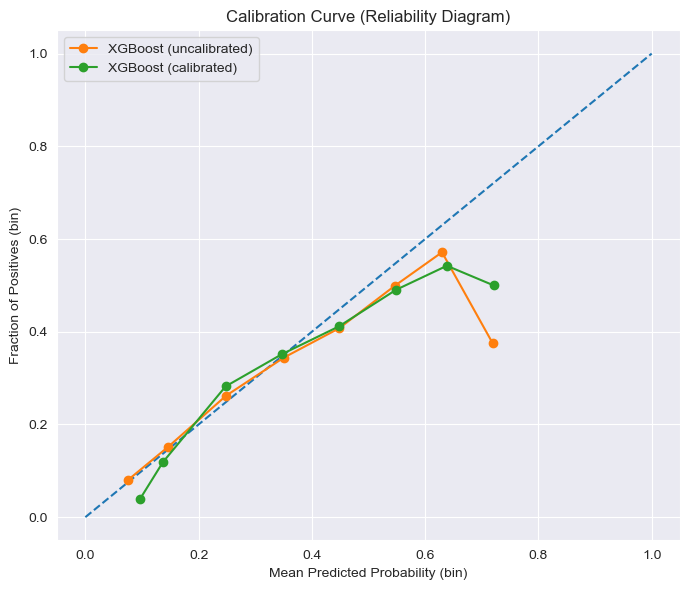

In [131]:

# ---------- 4) Calibration curve plot (reliability diagram) ----------
# Using sklearn.calibration.calibration_curve (like the link you shared)
n_bins = 10
frac_pos_uncal, mean_pred_uncal = calibration_curve(y_test, p_uncal, n_bins=n_bins, strategy="uniform")
frac_pos_cal, mean_pred_cal = calibration_curve(y_test, p_cal, n_bins=n_bins, strategy="uniform")

plt.figure(figsize=(7, 6))
# Perfect calibration line
plt.plot([0, 1], [0, 1], linestyle="--")

# Model curves
plt.plot(mean_pred_uncal, frac_pos_uncal, marker="o", label="XGBoost (uncalibrated)")
plt.plot(mean_pred_cal, frac_pos_cal, marker="o", label="XGBoost (calibrated)")

plt.title("Calibration Curve (Reliability Diagram)")
plt.xlabel("Mean Predicted Probability (bin)")
plt.ylabel("Fraction of Positives (bin)")
plt.legend()
plt.tight_layout()
plt.show()

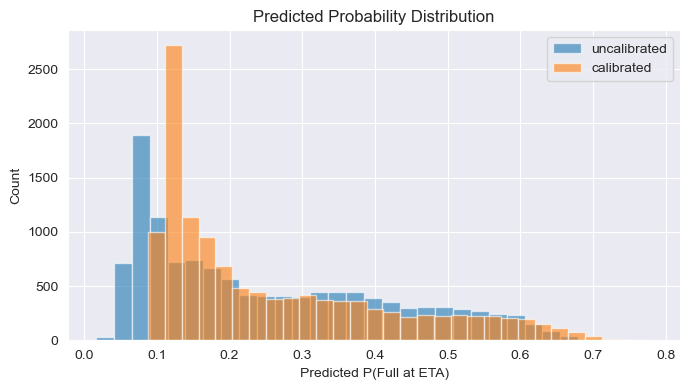

In [132]:
# Optional: histogram of predicted probabilities (helps explain threshold behavior)
plt.figure(figsize=(7, 4))
plt.hist(p_uncal, bins=30, alpha=0.6, label="uncalibrated")
plt.hist(p_cal, bins=30, alpha=0.6, label="calibrated")
plt.title("Predicted Probability Distribution")
plt.xlabel("Predicted P(Full at ETA)")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

In [135]:
thresholds = np.arange(0.05, 0.41, 0.05)

rows = []
for t in thresholds:
    pred = (p_uncal >= t).astype(int)
    tp = ((pred == 1) & (y_test == 1)).sum()
    fp = ((pred == 1) & (y_test == 0)).sum()
    fn = ((pred == 0) & (y_test == 1)).sum()

    recall = tp / (tp + fn)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0

    rows.append((t, recall, precision))

pd.DataFrame(rows, columns=["threshold", "recall_full", "precision_full"])


,threshold,recall_full,precision_full
0,0.05,0.998358,0.246773
1,0.10,0.914614,0.302192
2,0.15,0.842693,0.338210
3,0.20,0.765189,0.374357
4,0.25,0.700493,0.400413
5,0.30,0.617077,0.417370
6,0.35,0.519212,0.437950
7,0.40,0.415764,0.465270


In [136]:
threshold = 0.15
y_pred = (p_uncal >= threshold).astype(int)

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix (rows=true, cols=pred):")
print(cm)


Confusion Matrix (rows=true, cols=pred):
[[4361 5021]
 [ 479 2566]]
